In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import math
import random
import os

# ==========================================
# 0. 全局配置与设备设定
# ==========================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# 超参数 (对齐文档推荐值)
N_SHARES = 5           # n (total shares)
T_THRESH = 5           # t (threshold)
D_MODEL = 256          # d_model
width=8
D_SHARE = width*width        # d_share 大幅降低门限
IMG_SIZE = 28 * 28     # MNIST 展开维度

BATCH_SIZE = 128
EPOCHS_PHASE1 = 10     # Warmup (为方便演示缩短了epoch数)
EPOCHS_PHASE2 = 30     # Adversarial
EPOCHS_PHASE3 = 10     # Hardening

# 适当增加对抗阶段的权重
LAMBDA_ADV = 2

# 确保数据集路径匹配要求
os.makedirs("data/MNIST/raw", exist_ok=True)

# 数据加载
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1)) # 展平 28x28 -> 784
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)



Using device: cuda


In [2]:
# 1. 模型基础组件定义
# ==========================================
class ResidualBlock(nn.Module):
    """标准的残差块 Linear -> GELU -> Linear -> LayerNorm"""
    def __init__(self, dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, dim)
        )
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        return self.norm(x + self.net(x))


In [3]:
# 2. Encoder 架构 (分割)
# ==========================================
class Encoder(nn.Module):
    def __init__(self, input_dim=IMG_SIZE, d_model=D_MODEL, d_share=D_SHARE, n_shares=N_SHARES):
        super().__init__()
        self.n_shares = n_shares
        
        # Input projection
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model)
        )
        
        # Shared trunk: 2个残差块
        self.trunk = nn.Sequential(
            ResidualBlock(d_model, 4 * d_model),
            ResidualBlock(d_model, 4 * d_model)
        )
        
        # Share heads: n个完全独立的线性层
        self.share_heads = nn.ModuleList([
            nn.Linear(d_model, d_share) for _ in range(n_shares)
        ])

    def forward(self, x):
        features = self.trunk(self.input_proj(x))
        shares = []
        for head in self.share_heads:
            sh = head(features)
            # L2归一化，投影到单位超球面，避免幅度泄露秘密
            sh = torch.nn.functional.normalize(sh, p=2, dim=-1)
            shares.append(sh)
        # return shape: [batch, n_shares, d_share]
        return torch.stack(shares, dim=1)

def diversity_loss(shares):
    """
    计算 Diversity 正则: L_div = -log det(Sh * Sh^T / n)
    shares shape: [batch, n, d_share]
    """
    n = shares.size(1)
    # 计算 shares 之间的内积矩阵 (协方差/相似度)
    # shape: [batch, n, n]
    corr_matrix = torch.bmm(shares, shares.transpose(1, 2)) / n
    
    # 为了数值稳定，加上微小扰动
    eye = torch.eye(n, device=shares.device).unsqueeze(0)
    corr_matrix = corr_matrix + eye * 1e-5
    
    # 计算 log det
    # 有时由于浮点精度，矩阵可能不是严格正定，使用 torch.linalg.slogdet 更稳定
    sign, logabsdet = torch.linalg.slogdet(corr_matrix)
    
    # 期望行列式最大化 -> 最小化 -logdet
    loss_div = -logabsdet.mean()
    return loss_div


In [4]:
# 3. Decoder & Adversary 架构 (重建)
# ==========================================
class Decoder(nn.Module):
    def __init__(self, d_share=D_SHARE, d_model=D_MODEL, output_dim=IMG_SIZE):
        super().__init__()
        # Share embedding: 无位置编码，保证置换不变性
        self.share_embed = nn.Linear(d_share, d_model)
        
        # CLS token 作为聚合锚点
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        
        # Attention aggregation (Cross-attention)
        self.attention = nn.MultiheadAttention(embed_dim=d_model, num_heads=4, batch_first=True)
        
        # Decoder MLP: 2个残差块 (比Encoder略轻量)
        self.trunk = nn.Sequential(
            ResidualBlock(d_model, 2 * d_model),
            ResidualBlock(d_model, 2 * d_model)
        )
        
        self.output_proj = nn.Linear(d_model, output_dim)

    def forward(self, shares_subset):
        # shares_subset shape: [batch, k, d_share]
        B, k, _ = shares_subset.size()
        
        # 1. Embedding
        x = self.share_embed(shares_subset) # [B, k, d_model]
        
        # 2. 准备 CLS token (Query)
        cls_tokens = self.cls_token.expand(B, -1, -1) # [B, 1, d_model]
        
        # 3. Attention 聚合 (Q=cls, K=V=x)
        # attn_output shape: [B, 1, d_model]
        attn_output, _ = self.attention(query=cls_tokens, key=x, value=x)
        
        # 4. 解码
        features = self.trunk(attn_output.squeeze(1))
        out = self.output_proj(features)
        return torch.sigmoid(out) # 映射回 [0, 1] 像素空间


In [5]:
# 4. 训练逻辑与三阶段策略
# ==========================================
encoder = Encoder().to(DEVICE)
decoder = Decoder().to(DEVICE)
adversary = Decoder().to(DEVICE) # Adversary D 结构与 Decoder 相同

opt_E = optim.Adam(encoder.parameters(), lr=3e-4)
opt_D_recon = optim.Adam(decoder.parameters(), lr=3e-4)
opt_D_adv = optim.Adam(adversary.parameters(), lr=1e-4) # 学习率比 Encoder 慢

criterion_mse = nn.MSELoss()

def train_phase_1_warmup(epochs=EPOCHS_PHASE1):
    print("--- Phase 1: Warmup 建立重建能力 ---")
    encoder.train()
    decoder.train()
    gamma = 0.05
    
    for epoch in range(epochs):
        total_loss = 0
        for batch_idx, (data, _) in enumerate(train_loader):
            data = data.to(DEVICE)
            
            opt_E.zero_grad()
            opt_D_recon.zero_grad()
            
            shares = encoder(data)
            reconstructed = decoder(shares) # 使用全部 n 个 shares
            
            l_recon = criterion_mse(reconstructed, data)
            l_div = diversity_loss(shares)
            
            loss = l_recon + gamma * l_div
            loss.backward()
            
            opt_E.step()
            opt_D_recon.step()
            
            total_loss += loss.item()
            
        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f}")

def train_phase_2_adversarial(epochs=EPOCHS_PHASE2):
    print("\n--- Phase 2: Adversarial 显式噪声诱导 ---")
    encoder.train()
    decoder.train()
    adversary.train()
    
    gamma = 0.05
    lambda_adv_max = LAMBDA_ADV
    total_steps = epochs * len(train_loader)
    step = 0
    
    for epoch in range(epochs):
        recon_loss_avg = 0
        adv_loss_avg = 0
        
        for batch_idx, (data, _) in enumerate(train_loader):
            data = data.to(DEVICE)
            B = data.size(0)
            step += 1
            lambda_adv = min(lambda_adv_max, lambda_adv_max * (step / (total_steps * 0.5)))
            
            # --- 1. Adversary 更新 (D 尝试从 k < t 中恢复) ---
            opt_D_adv.zero_grad()
            with torch.no_grad():
                shares = encoder(data)
            
            k_adv = random.randint(1, T_THRESH - 1)
            indices = torch.randperm(N_SHARES)[:k_adv]
            shares_adv = shares[:, indices, :]
            
            s_adv_recon = adversary(shares_adv)
            loss_D_adv = criterion_mse(s_adv_recon, data) 
            loss_D_adv.backward()
            opt_D_adv.step()
            
            # --- 2. Encoder / Decoder 更新 ---
            opt_E.zero_grad()
            opt_D_recon.zero_grad()
            
            shares = encoder(data)
            reconstructed = decoder(shares)
            l_recon = criterion_mse(reconstructed, data)
            l_div = diversity_loss(shares)
            
            # 【核心修复】：Encoder 迫使 Adversary 输出均匀随机噪声
            shares_adv_for_E = shares[:, indices, :]
            s_adv_recon_for_E = adversary(shares_adv_for_E)
            
            # 生成与原图同尺寸的纯随机噪声 [0, 1]
            noise_target = torch.rand_like(data).to(DEVICE)
            
            # 让 Encoder 的目标是：最小化 D 输出与纯噪声的差异
            l_adv_penalty = criterion_mse(s_adv_recon_for_E, noise_target) 
            
            # 这里变成加上 l_adv_penalty，因为我们希望它逼近噪声靶标
            loss_E = l_recon + lambda_adv * l_adv_penalty + gamma * l_div
            loss_E.backward()
            
            opt_E.step()
            opt_D_recon.step()
            
            recon_loss_avg += l_recon.item()
            adv_loss_avg += loss_D_adv.item() 
            
        print(f"Epoch {epoch+1}/{epochs} | L_recon: {recon_loss_avg/len(train_loader):.4f} | L_adv (D Error): {adv_loss_avg/len(train_loader):.4f}")
        
def train_phase_3_hardening(epochs=EPOCHS_PHASE3):
    print("\n--- Phase 3: Hardening Curriculum 门限收紧 ---")
    # k 从 n 逐步收缩到 t
    gamma = 0.05
    for epoch in range(epochs):
        # Curriculum Schedule: 随 epoch 降低 k
        k_curr = max(T_THRESH, N_SHARES - int((N_SHARES - T_THRESH) * (epoch / (epochs * 0.5))))
        
        total_loss = 0
        for batch_idx, (data, _) in enumerate(train_loader):
            data = data.to(DEVICE)
            
            opt_E.zero_grad()
            opt_D_recon.zero_grad()
            
            shares = encoder(data)
            
            # 随机挑选 k_curr 个 shares 给 Decoder
            indices = torch.randperm(N_SHARES)[:k_curr]
            shares_subset = shares[:, indices, :]
            
            reconstructed = decoder(shares_subset)
            l_recon = criterion_mse(reconstructed, data)
            l_div = diversity_loss(shares)
            
            loss = l_recon + gamma * l_div
            loss.backward()
            
            opt_E.step()
            opt_D_recon.step()
            total_loss += loss.item()
            
        print(f"Epoch {epoch+1}/{epochs} | k_curr: {k_curr} | L_recon: {total_loss/len(train_loader):.4f}")

In [6]:

# 执行训练
train_phase_1_warmup()
train_phase_2_adversarial()
#train_phase_3_hardening()


--- Phase 1: Warmup 建立重建能力 ---
Epoch 1/10 | Loss: 0.4426
Epoch 2/10 | Loss: 0.4123
Epoch 3/10 | Loss: 0.4079
Epoch 4/10 | Loss: 0.4062
Epoch 5/10 | Loss: 0.4054
Epoch 6/10 | Loss: 0.4049
Epoch 7/10 | Loss: 0.4046
Epoch 8/10 | Loss: 0.4044
Epoch 9/10 | Loss: 0.4042
Epoch 10/10 | Loss: 0.4041

--- Phase 2: Adversarial 显式噪声诱导 ---
Epoch 1/30 | L_recon: 0.0019 | L_adv (D Error): 0.0780
Epoch 2/30 | L_recon: 0.0022 | L_adv (D Error): 0.0583
Epoch 3/30 | L_recon: 0.0026 | L_adv (D Error): 0.0580
Epoch 4/30 | L_recon: 0.0028 | L_adv (D Error): 0.0604
Epoch 5/30 | L_recon: 0.0025 | L_adv (D Error): 0.0615
Epoch 6/30 | L_recon: 0.0026 | L_adv (D Error): 0.0622
Epoch 7/30 | L_recon: 0.0025 | L_adv (D Error): 0.0641
Epoch 8/30 | L_recon: 0.0025 | L_adv (D Error): 0.0645
Epoch 9/30 | L_recon: 0.0023 | L_adv (D Error): 0.0656
Epoch 10/30 | L_recon: 0.0025 | L_adv (D Error): 0.0652
Epoch 11/30 | L_recon: 0.0025 | L_adv (D Error): 0.0648
Epoch 12/30 | L_recon: 0.0027 | L_adv (D Error): 0.0651
Epoch 13


--- Testing & Visualization ---


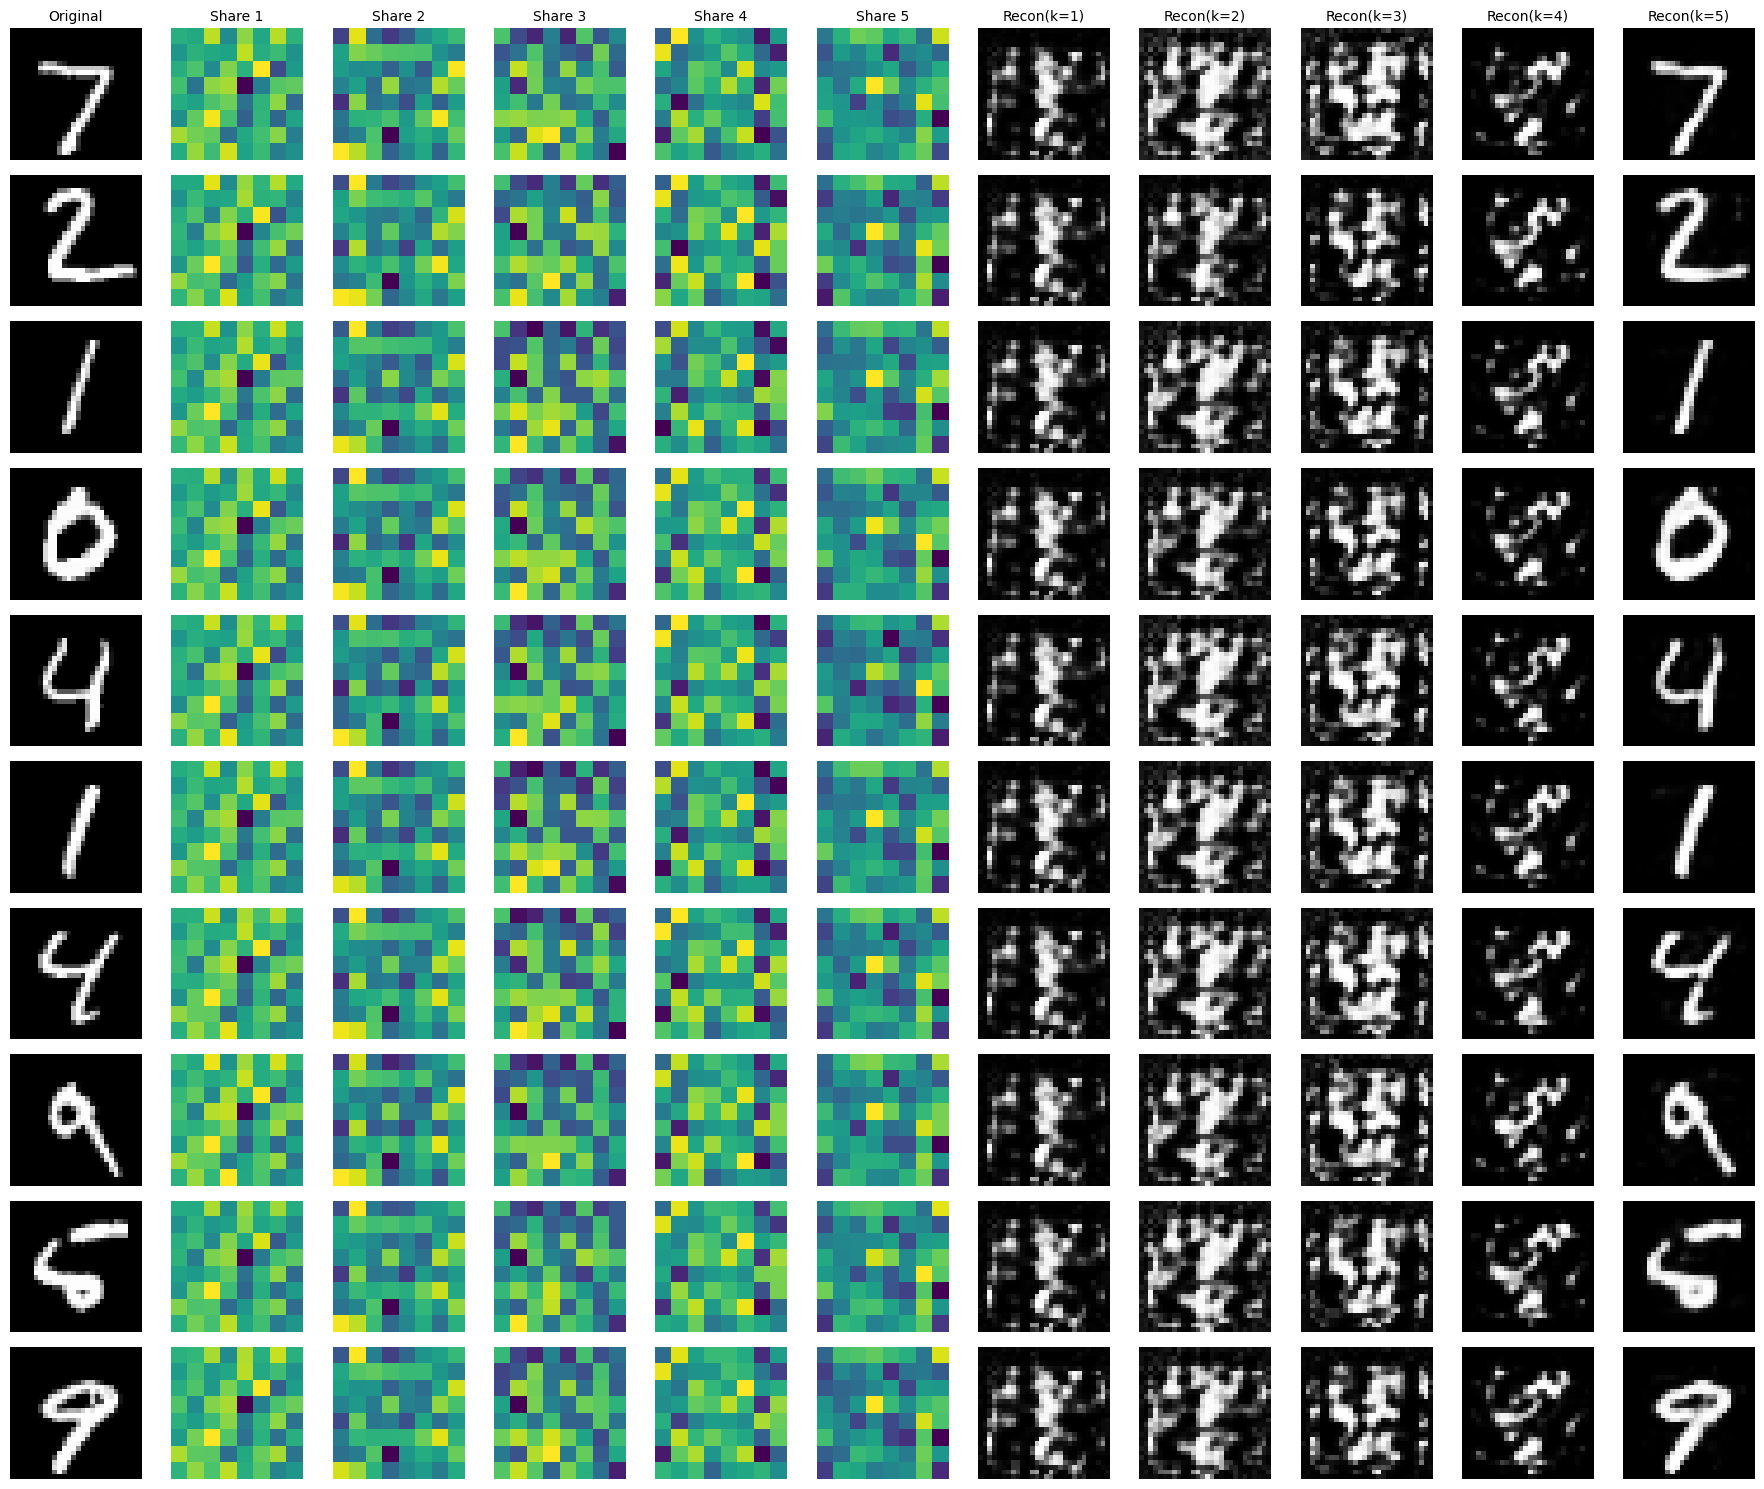

In [7]:
# 5. 测试与可视化模块
# ==========================================
def test_and_visualize(num_images=10):
    print("\n--- Testing & Visualization ---")
    encoder.eval()
    decoder.eval()
    
    # 获取 10 张测试集图片
    data_iter = iter(test_loader)
    images, _ = next(data_iter)
    images = images[:num_images].to(DEVICE)
    
    with torch.no_grad():
        shares = encoder(images) # [10, 5, 128]
        
        # 准备画布 (10行， 1+5+5 = 11列)
        # 列: 原图 | S1 | S2 | S3 | S4 | S5 | k=1 | k=2 | k=3 | k=4 | k=5
        fig, axes = plt.subplots(num_images, 11, figsize=(18, 1.5 * num_images))
        plt.subplots_adjust(wspace=0.1, hspace=0.1)
        
        col_titles = ['Original', 'Share 1', 'Share 2', 'Share 3', 'Share 4', 'Share 5', 
                      'Recon(k=1)', 'Recon(k=2)', 'Recon(k=3)', 'Recon(k=4)', 'Recon(k=5)']
        
        for i in range(num_images):
            # 1. 原图
            orig_img = images[i].view(28, 28).cpu().numpy()
            axes[i, 0].imshow(orig_img, cmap='gray')
            axes[i, 0].axis('off')
            if i == 0: axes[i, 0].set_title(col_titles[0], fontsize=10)
            
            # 2. 5个Shares的伪可视化 (reshape 128 to 8x16)
            for j in range(5):
                share_img = shares[i, j].view(width, width).cpu().numpy()
                axes[i, j+1].imshow(share_img, cmap='viridis')
                axes[i, j+1].axis('off')
                if i == 0: axes[i, j+1].set_title(col_titles[j+1], fontsize=10)
                
            # 3. 动态 k 个 shares 重建
            for k in range(1, 6):
                # 选取前 k 个 shares进行重建
                k_shares = shares[i:i+1, :k, :] # shape: [1, k, 128]
                recon_out = decoder(k_shares)
                recon_img = recon_out.view(28, 28).cpu().numpy()
                
                # 如果 k < 3 (t=3)，模型预期应该无法重建出清晰图像（模糊或白噪声）
                axes[i, k+5].imshow(recon_img, cmap='gray')
                axes[i, k+5].axis('off')
                if i == 0: axes[i, k+5].set_title(col_titles[k+5], fontsize=10)

        plt.tight_layout()
        plt.show()

# 运行测试与可视化
test_and_visualize(num_images=10)
